In [1]:
import numpy as np
import trimesh
import matplotlib.pyplot as plt

In [2]:
from photontracer import Simulation, Material, MaterialType, MeshGeometry, IsotropicRayGenerator, OutputType, LengthUnit

In [3]:
# create a mesh representation af a sphere
grs_mesh = trimesh.load_mesh('data/GS_0.1_3_2-7.obj')
grs_scaled = grs_mesh.copy()
grs_scaled.vertices *= 0.1  # scale to 0.1 mm
grs_geometry = MeshGeometry(grs_scaled.vertices, grs_scaled.faces)

In [4]:
grs_mesh.show()

In [5]:
wavelength_um = 1.5  # green light

materials = [
    Material(MaterialType.REFRACTIVE, 1+0j),  # vacuum
    Material(MaterialType.REFRACTIVE, 1.33+1e-5j) # water
]

In [6]:
sim = Simulation(0)
sim.length_unit = LengthUnit.MILLI_METER

Selecting GPU device ID: 1/1
Using device: NVIDIA GeForce RTX 3090


In [7]:
sim.geometry = grs_geometry
sim.materials = materials
sim.wavelength_um = wavelength_um

In [8]:
number_of_rays = 100_000_000
sim.ray_generator = IsotropicRayGenerator(
    number_of_rays=number_of_rays,
    center=(0, 0, 0),
    source_radius=1,
    offset_radius=1.165294*0.1
)

In [9]:
sim.outputs = [
    OutputType.RAY_STATE, OutputType.SCATTERING_COUNT,
    OutputType.STOKES_VECTOR, OutputType.STOKES_VECTOR_IN, 
    OutputType.SCATTERING_ANGLE
]

In [10]:
def run_sim(sim, stokes):
    sim.stokes_vector = stokes
    sim.max_scattering_count = 100
    sim.run()
    stokes = sim.get_output_buffer(OutputType.STOKES_VECTOR)
    stokes_in = sim.get_output_buffer(OutputType.STOKES_VECTOR_IN)
    ray_state = sim.get_output_buffer(OutputType.RAY_STATE)
    scattering_count = sim.get_output_buffer(OutputType.SCATTERING_COUNT)
    angle = sim.get_output_buffer(OutputType.SCATTERING_ANGLE)

    no_hit = scattering_count == 0
    absorbed = ray_state == 1
    max_scattering = scattering_count >= 100


    escape = ~(no_hit | absorbed | max_scattering)
    
    print(f"Q_abs={absorbed.sum()/(escape.sum()+absorbed.sum()):.5f}")

    s_o = stokes[escape]
    s_i = stokes_in[escape]
    depth_o = scattering_count[escape]
    an = angle[escape]
    return an, s_o, s_i, depth_o

In [11]:
angle, s_o, s_i, scattering_count_o = run_sim(sim, (1.0, np.nan, np.nan, 0.0))
angle_c, s_o_c, s_i_c, scattering_count_o_c = run_sim(sim, (1.0, 0.0, 0.0, np.nan))

Starting simulation
Finished raytracing in 7853 ms
Q_abs=0.01879
Starting simulation
Finished raytracing in 7856 ms
Q_abs=0.01879


In [12]:
nbins = 61
bin_edges = np.linspace(0.0, np.pi, nbins+1)   # radians

In [13]:
hist_counts, _ = np.histogram(angle, bins=bin_edges)
# bin centers and widths
centers = 0.5*(bin_edges[:-1] + bin_edges[1:])
dtheta = bin_edges[1] - bin_edges[0]

# solid angle of ring (unit sphere)
dOmega = 2.0 * np.pi * np.sin(centers) * dtheta

# intensity per steradian (compare to p11-like phase functions)
intensity_per_sr = hist_counts / dOmega

p11 = 4 * np.pi * intensity_per_sr / len(angle)

In [14]:
def average_per_angle(value_array, bin_idx):
    average_value = np.zeros(np.max(bin_idx)+1)
    sums = np.bincount(bin_idx, weights=value_array, minlength=nbins)
    counts = np.bincount(bin_idx, minlength=nbins)
    # Avoid division by zero
    average_value = np.divide(sums, counts, out=np.zeros_like(sums), where=counts > 0)
    return average_value

In [15]:
centers_degrees = centers / np.pi * 180.0  # degrees

In [16]:
nbins = len(bin_edges) - 1
bin_idx = np.digitize(angle, bins=bin_edges) - 1
bin_idx[bin_idx < 0] = 0
bin_idx[bin_idx >= nbins] = nbins-1

In [17]:
nbins = len(bin_edges) - 1
bin_idx_c = np.digitize(angle_c, bins=bin_edges) - 1
bin_idx_c[bin_idx_c < 0] = 0
bin_idx_c[bin_idx_c >= nbins] = nbins-1

In [18]:
m11 = average_per_angle(s_o[:,0], bin_idx)
m21 = average_per_angle(s_o[:,1], bin_idx)
m22 = average_per_angle(2 * s_o[:,1] * s_i[:,1], bin_idx)
m23 = average_per_angle(2 * s_o[:,1] * s_i[:,2], bin_idx)
m32 = average_per_angle(2 * s_o[:,2] * s_i[:,1], bin_idx)
m33 = average_per_angle(2 * s_o[:,2] * s_i[:,2], bin_idx)
m43 = average_per_angle(2 * s_o[:,3] * s_i[:,2], bin_idx)
m44 = average_per_angle(2 * s_o_c[:,3] * s_i_c[:,3], bin_idx_c)


In [19]:
siris_output_S = np.loadtxt("data/GRS_SIRIS-S.out")

In [20]:
angles_siris = siris_output_S.T[0]
p = siris_output_S.T[1:].reshape((4, 4, 61))
p.shape

(4, 4, 61)

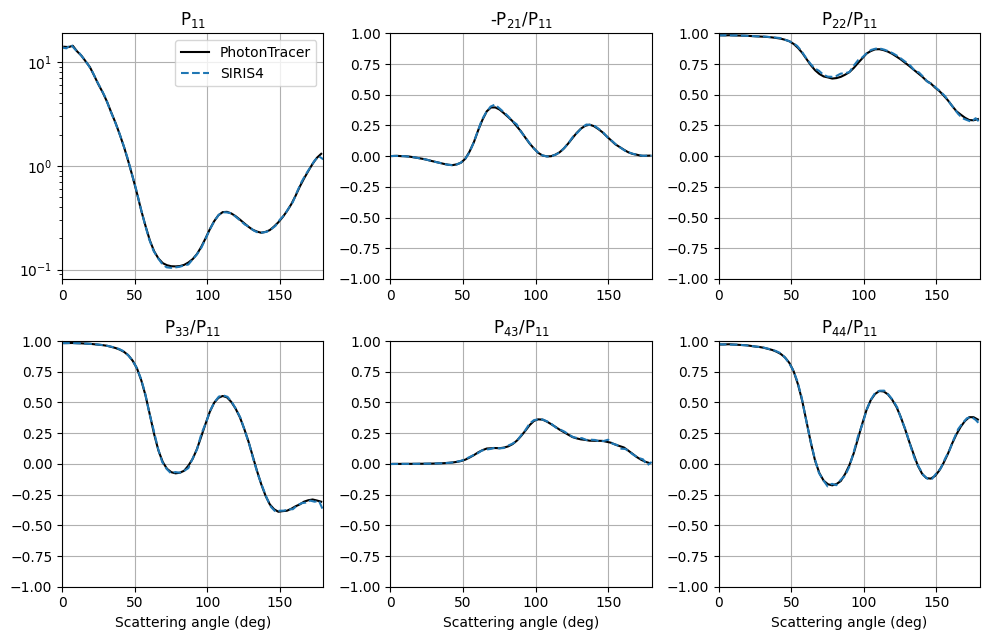

In [21]:
#plot histogram of scattering angles
import matplotlib as mpl
# use tableau colorblind-friendly
colors = mpl.cm.tab10.colors

fig, ax = plt.subplots(2,3, figsize=(10, 6.5))

ax[0, 0].plot(centers_degrees, p11, label="PhotonTracer", color='black')
ax[0, 1].plot(centers_degrees, -m21, label="PhotonTracer P21/P11", color='black')
ax[0, 2].plot(centers_degrees, m22, label="PhotonTracer P22/P11", color='black')
ax[1, 0].plot(centers_degrees, m33, label="PhotonTracer P23/P11", color='black')
ax[1, 1].plot(centers_degrees, m43, label="PhotonTracer P43/P11", color='black')
ax[1, 2].plot(centers_degrees, m44, label="PhotonTracer P44/P11", color='black')


ax[0, 0].plot(angles_siris, p[0,0,:], label="SIRIS4", ls='--')
ax[0, 1].plot(angles_siris, -p[1,0]/p[0,0], label="SIRIS4 P21/P11", ls='--')
ax[0, 2].plot(angles_siris, p[1,1]/p[0,0], label="SIRIS4 P22/P11", ls='--')
ax[1, 0].plot(angles_siris, p[2,2]/p[0,0], label="SIRIS4 P33/P11", ls='--')
ax[1, 1].plot(angles_siris, p[3,2]/p[0,0], label="SIRIS4 P43/P11", ls='--')
ax[1, 2].plot(angles_siris, p[3,3]/p[0,0], label="SIRIS4 P44/P11", ls='--')

ax[0, 0].set_title("P$_{11}$")
ax[0, 0].set_yscale("log")
ax[0, 1].set_title("-P$_{21}$/P$_{11}$")
ax[0, 2].set_title("P$_{22}$/P$_{11}$")
ax[1, 0].set_title("P$_{33}$/P$_{11}$")
ax[1, 1].set_title("P$_{43}$/P$_{11}$")
ax[1, 2].set_title("P$_{44}$/P$_{11}$")

ax[0, 0].legend()


#plt.ylabel("-p21/p11")
for i in range(3):
    if i != 0:
        ax[0, i].set_ylim([-1., 1.])
    ax[1, i].set_ylim([-1., 1.])
    ax[1, i].set_xlabel("Scattering angle (deg)")


    for j in range(2):
        ax[j, i].grid()
        ax[j, i].set_xlim([0, 180])

fig.tight_layout()